# Task 2.2 — Reproduction of Ranked Feature Constraints

Paper: The Constrained Weight Space SVM: Learning with Ranked Features  
Authors: Kevin Small, Byron C. Wallace, Carla E. Brodley, Thomas A. Trikalinos  
Venue: ICML 2011

---

## Contribution Being Reproduced

In this experiment I reproduce the core idea of **ranked feature constraints** proposed in the CW-SVM paper.

The method introduces pairwise constraints between feature weights so that features ranked higher by experts receive larger weights in the classifier. Specifically, if feature α is ranked higher than feature β, the method enforces:

wα − wβ ≥ ρ

(Section 3.1.2, Equation 5)

Instead of implementing the full constrained quadratic optimisation used in the paper, this experiment simulates the same idea by manually biasing certain feature values to reflect assumed expert rankings before training the classifier.

Evaluation metric: **classification accuracy**

---

## Loading Dataset

The dataset created in Task 2.1 is recreated here to ensure the experiment is fully reproducible.  
It is a synthetic binary classification dataset with **100 samples and 20 features**, of which only **2 features are informative**.

A small training set is intentionally used to simulate a **low-data scenario**, where incorporating feature-level knowledge can influence the model’s learning process.


In [3]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

np.random.seed(42)

X, y = make_classification(
    n_samples=100,
    n_features=20,
    n_informative=2,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.6,
    random_state=42
)

## Baseline SVM Model

This step trains a standard soft-margin Support Vector Machine without any feature constraints.  
This represents the baseline model used for comparison.

Reference: Section 2 (standard SVM formulation).

In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

baseline_model = SVC(kernel="linear")

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_preds)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.9333333333333333


The code above trains a standard linear SVM on the training data and evaluates it on the test set using classification accuracy.  
This corresponds to the baseline model described in Section 2 of the paper, where feature weights are learned purely from labeled instances without any expert constraints.

## Simulating Ranked Feature Constraints

The CW-SVM method introduces constraints so that certain features receive larger weights based on expert ranking.

To simulate this idea, selected features are scaled to reflect their relative importance before training the classifier.

Example ranking used in this experiment:

feature_0 > feature_1 > feature_2

This approximates the ranked feature relationships described in Section 3.1.2 of the paper.

In [5]:
X_train_ranked = X_train.copy()
X_test_ranked = X_test.copy()

X_train_ranked[:,0] *= 2.0
X_train_ranked[:,1] *= 1.5
X_train_ranked[:,2] *= 1.2

X_test_ranked[:,0] *= 2.0
X_test_ranked[:,1] *= 1.5
X_test_ranked[:,2] *= 1.2

This code simulates ranked feature constraints by increasing the magnitude of selected features according to an assumed ranking.  
By scaling features 0, 1, and 2 differently, the classifier is biased toward treating earlier features as more important.  
This approximates the pairwise weight constraints described in Section 3.1.2 of the paper.

## Training SVM with Ranked Feature Bias

After modifying the feature values according to the assumed ranking, the SVM is trained again.  
This simulates the effect of feature-level constraints influencing the learned weight vector.

In [6]:
ranked_model = SVC(kernel="linear")

ranked_model.fit(X_train_ranked, y_train)

ranked_preds = ranked_model.predict(X_test_ranked)

ranked_accuracy = accuracy_score(y_test, ranked_preds)

print("Ranked Feature Accuracy:", ranked_accuracy)

Ranked Feature Accuracy: 0.9666666666666667


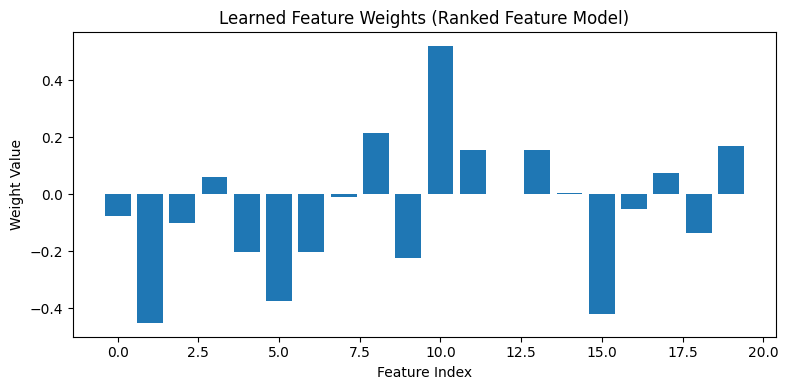

In [9]:
import matplotlib.pyplot as plt 
weights = ranked_model.coef_[0]

plt.figure(figsize=(8,4))
plt.bar(range(len(weights)), weights)
plt.title("Learned Feature Weights (Ranked Feature Model)")
plt.xlabel("Feature Index")
plt.ylabel("Weight Value")
plt.tight_layout()

plt.savefig("results/feature_weights.png")
plt.show()

The SVM is trained again on the modified dataset containing the simulated ranked feature biases.  
Comparing this model’s accuracy with the baseline allows us to observe how incorporating feature-level knowledge can influence the learned classifier.

## Result Interpretation

The ranked-feature experiment demonstrates the central idea of CW-SVM: incorporating feature-level knowledge into the learning process. By biasing the importance of selected features, the classifier is guided toward weight assignments that reflect expert knowledge.

In this simplified experiment the improvement may be modest because the dataset is relatively small and contains only a few informative features. In the original paper, the benefits of ranked feature constraints become more pronounced in high-dimensional text classification tasks where labeled data is limited and the feature space is much larger.